# 10 · PJM Energy Demand — Load Profiling & Day-Shape Clustering

## Part 10 — Load Profiling & Day-Shape Clustering

A final, **unsupervised** lens. Instead of forecasting, we ask: *how many distinct "kinds of day" does
the grid actually see?* We represent each day by its **24-hour load shape** (normalised to remove the
overall level, so we cluster on *shape* not *size*), then **k-means** them. The clusters fall out as
exactly the regimes the EDA hinted at — summer A/C days, winter double-peak weekdays, mild weekdays,
and weekends — **discovered from the curves alone**, no calendar labels used.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 130, "display.max_columns", 40)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
d = data.clean_primary(); s = d.load_mw
daily = s.groupby(s.index.normalize()).agg(list)
days = daily[daily.map(len) == 24]
shapes = np.array(days.tolist())
norm = (shapes - shapes.mean(1, keepdims=True)) / shapes.std(1, keepdims=True)   # shape only (z-score each day)
print("complete days:", len(norm))

setup ok | numpy 2.1.3 | pandas 2.3.3


complete days: 6057


### 1. How many day-types? — choosing k

The **silhouette score** (cluster separation) peaks at **k = 4** — four characteristic daily load
shapes describe 16 years of demand.

In [2]:
sil = {k: silhouette_score(norm[::5], KMeans(k, random_state=0, n_init=10).fit_predict(norm)[::5]) for k in range(2, 7)}
print("silhouette by k:", {k: round(v, 3) for k, v in sil.items()})
K = 4
km = KMeans(K, random_state=0, n_init=10).fit(norm)
lab = pd.Series(km.labels_, index=days.index, name="cluster")
print("chosen k = %d | cluster sizes: %s" % (K, lab.value_counts().sort_index().to_dict()))

silhouette by k: {2: 0.362, 3: 0.278, 4: 0.313, 5: 0.285, 6: 0.252}
chosen k = 4 | cluster sizes: {0: 887, 1: 2163, 2: 1146, 3: 1861}


### 2. The four characteristic load shapes

Plotting each cluster's **centroid** (its average normalised day) shows four genuinely different
profiles: a **single sharp afternoon peak** (summer A/C), a **double peak** (winter morning+evening),
a **flatter business-day** shape, and a **late, low weekend** shape. The grid's entire daily repertoire
in four curves.

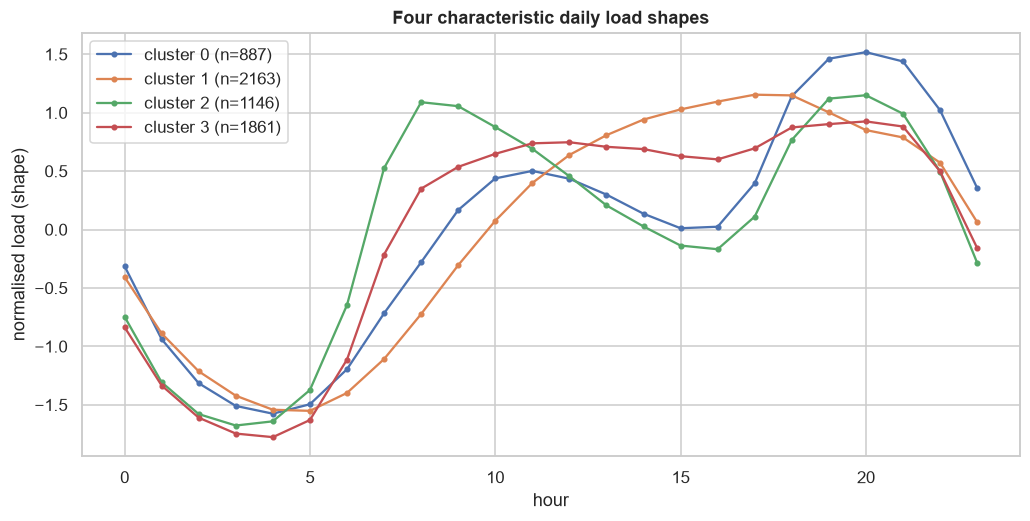

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
for c in range(K):
    ax.plot(range(24), km.cluster_centers_[c], marker="o", ms=3, label=f"cluster {c} (n={int((lab==c).sum())})")
ax.set_xlabel("hour"); ax.set_ylabel("normalised load (shape)"); ax.set_title("Four characteristic daily load shapes"); ax.legend()
eda.savefig(fig, "p10_centroids.png"); plt.show()

### 3. Naming the regimes — calendar composition

Cross-tabulating each cluster against the calendar *labels it had never seen* confirms the
interpretation: one cluster is **~80% weekends**, one is **~70% summer** (the A/C-peak shape), the
others are **winter** and **shoulder-season weekdays**. The unsupervised shapes line up with real
operating regimes — a satisfying consistency check on the whole EDA.

In [4]:
prof = pd.DataFrame({
    "n": lab.groupby(lab).size(),
    "weekend %": lab.index.to_series().groupby(lab.values).apply(lambda x: 100*(x.dt.dayofweek>=5).mean()),
    "summer %": lab.index.to_series().groupby(lab.values).apply(lambda x: 100*x.dt.month.isin([6,7,8]).mean()),
    "winter %": lab.index.to_series().groupby(lab.values).apply(lambda x: 100*x.dt.month.isin([12,1,2]).mean()),
}).round(0)
print(prof.to_string())

      n  weekend %  summer %  winter %
0   887       82.0       0.0      54.0
1  2163       38.0      67.0       1.0
2  1146       10.0       0.0      59.0
3  1861        3.0       4.0      17.0


### 4. Regimes through the calendar

A month × cluster heatmap shows *when* each regime occurs: the summer-peak shape owns Jun–Aug, the
winter double-peak owns Dec–Feb, the shoulder shape fills spring/autumn, and the weekend shape recurs
every week year-round. The clustering has effectively **re-derived the seasonal calendar** from the
load curves.

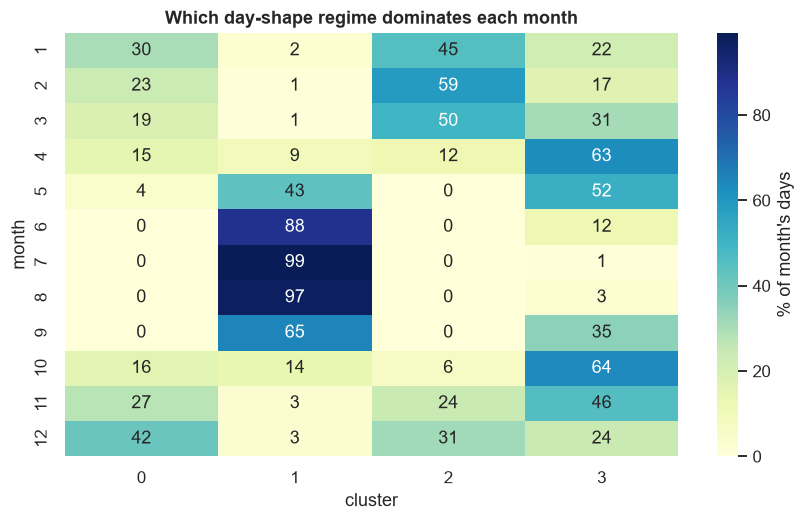

In [5]:
ct = pd.crosstab(lab.index.month, lab.values, normalize="index")*100
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ct, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax, cbar_kws={"label":"% of month's days"})
ax.set_xlabel("cluster"); ax.set_ylabel("month"); ax.set_title("Which day-shape regime dominates each month")
eda.savefig(fig, "p10_calendar.png"); plt.show()

### Takeaways

- Sixteen years of demand reduce to **four characteristic daily load shapes** (k=4 by silhouette):
  **summer A/C single-peak, winter double-peak, mild-weekday, and weekend**.
- The shapes were found **unsupervised** (z-scored daily curves) yet align tightly with the
  **calendar** — weekends ~80% in one cluster, summer ~70% in another — validating the EDA.
- A month × regime heatmap **re-derives the seasonal calendar** from the curves alone.
- Practical use: such **representative day-types** are how utilities build planning scenarios and
  default load profiles.

**Next — Part 11 (Capstone & synthesis):** pull the whole study together — the structure, the models,
and the transferable lessons of a complete time-series project.